Number of 6's correctly classified: 1378


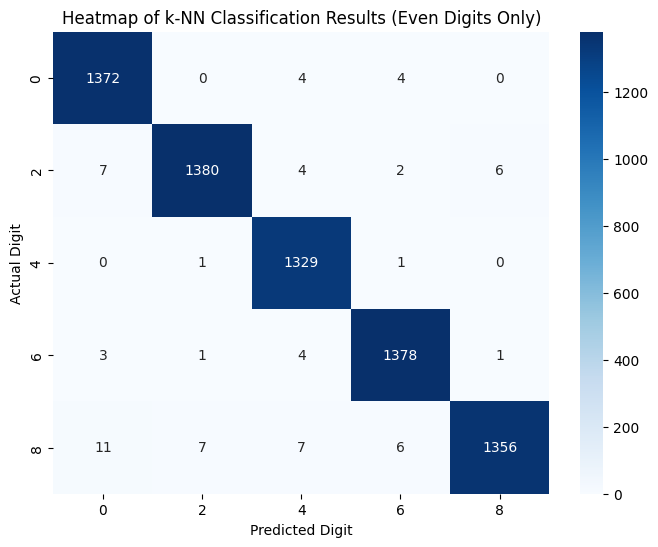

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# 1. Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

# 2. Filter data to include ONLY even numbers
even_mask = (y % 2 == 0)
X_even = X[even_mask]
y_even = y[even_mask]

# 3. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_even, y_even, test_size=0.2, random_state=42)

# 4. Train the k-NN classifier
knn = KNeighborsClassifier(n_neighbors=3) # You can adjust 'k' if specified in class
knn.fit(X_train, y_train)

# 5. Make predictions
y_pred = knn.predict(X_test)

# 6. Calculate Confusion Matrix for the Heatmap
even_classes = [0, 2, 4, 6, 8]
cm = confusion_matrix(y_test, y_pred, labels=even_classes)

# 7. Find how many 6's were correctly classified
# The index of '6' in classes array [0, 2, 4, 6, 8] is 3. 
# cm[3, 3] gives the true positives for 6.
correct_6s = cm[3, 3]
print(f"Number of 6's correctly classified: {correct_6s}")

# 8. Plot the classification results using a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=even_classes, yticklabels=even_classes)
plt.title('Heatmap of k-NN Classification Results (Even Digits Only)')
plt.xlabel('Predicted Digit')
plt.ylabel('Actual Digit')
plt.show()